## Week3 Assignment 1

##### Submitted by: Sanskriti Karn
##### IT-2
##### 11401032025

#### Part A: Understanding the Dataset
##### Q1. Dataset Overview 

In [39]:
import pandas as pd

#Load the dataset
df=pd.read_csv("agriculture_yield_dataset.csv")

#Number of rows and columns
print("Rows and columns: ", df.shape)

#Column names
print("Columns names are: ")
print(df.columns)

#Print first 10 records
print(df.head(10))

Rows and columns:  (1500, 8)
Columns names are: 
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4    

##### Q2. Data Types and Missing Values

In [40]:
#Data types
print("Data Types: ")
print(df.dtypes)

#Missing values
print("\nMissing values: ")
print(df.isnull().sum())

#Columns having missing values
print("\nColumns having missing values: ")
print(df.columns[df.isnull().sum()>0])

Data Types: 
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing values: 
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Columns having missing values: 
Index([], dtype='object')


##### Q3. Descriptive Statistics

In [15]:
#Summary statistics
print(df.describe())

#Highest mean value
print("\nHighest mean is: ")
print(df.describe().loc['mean'].idxmax())

#Highest standard deviation
print("Highest standard deviation: ")
print(df.describe().loc['std'].idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

#### Part B: Exploratory Data Analysis (EDA)

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

##### Q4. Distribution Analysis

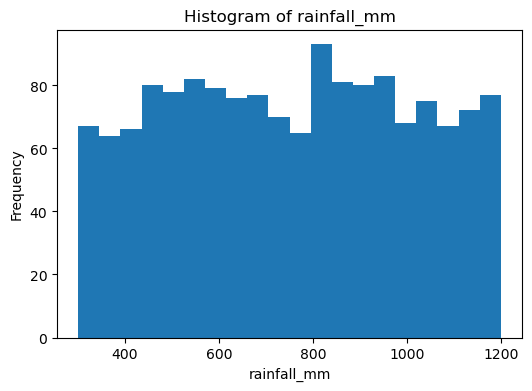

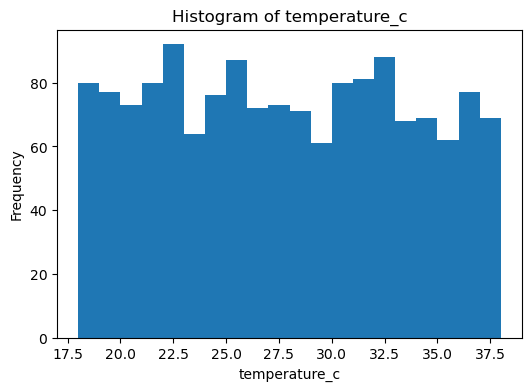

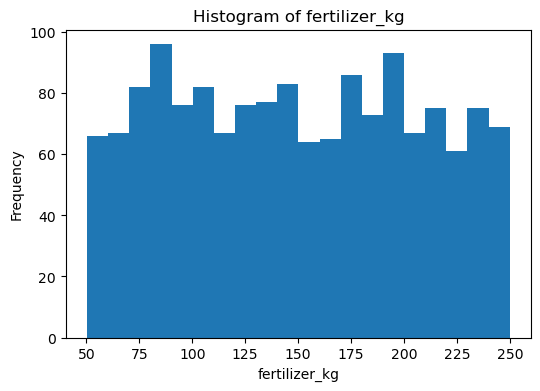

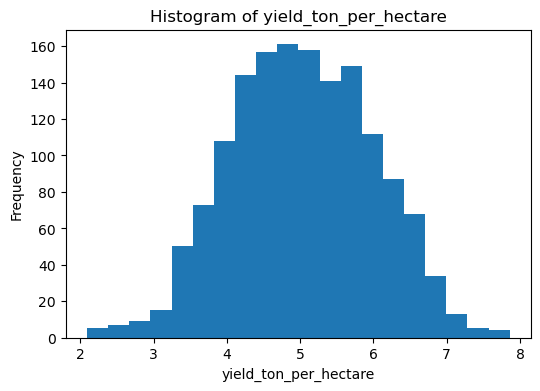

In [18]:
cols = [
    "rainfall_mm",
    "temperature_c",
    "fertilizer_kg",
    "yield_ton_per_hectare"
]

for col in cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

##### Observations
1. rainfall_mm          
-Most values lie between 500 mm and 1000 mm.       
-The graph does not show any strong skewness and looks fairly balanced.          
-No significant outliers are present.          
2. temperature_c          
-Most temperature values lie between 22°C and 33°C.          
-The distribution appears fairly symmetric.          
-No noticeable outliers are visible.          
3. fertilizer_kg          
-Most farmers use fertilizer between 100 kg and 200 kg.          
-The distribution is fairly uniform/symmetric across the range.          
-No major outliers are present.          
4. yield_ton_per_hectare          
-Yield values mostly lie in the range 4 to 6 tons per hectare.          
-The distribution is approximately bell-shaped (close to normal).          
-Very few outliers are visible (only a small number of extreme values).          

##### Q5. Crop Type Analysis

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


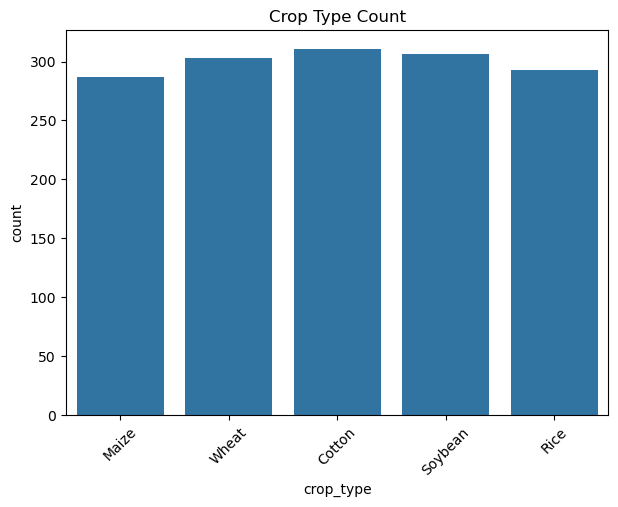


Most Frequent Crop:
Cotton


In [19]:
#Frequency of each group
print(df['crop_type'].value_counts())

#Count plot
plt.figure(figsize=(7,5))
sns.countplot(x='crop_type',data=df)

plt.title("Crop Type Count")
plt.xticks(rotation=45)
plt.show()

# Most frequent crop
print("\nMost Frequent Crop:")
print(df['crop_type'].mode()[0])

##### Q6. Soil Type Analysis

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


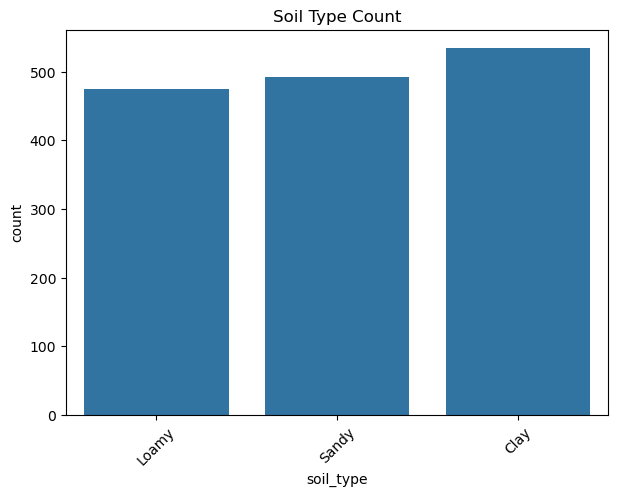

Most Common Soil:
Clay


In [21]:
# Frequency
print(df['soil_type'].value_counts())

# Count plot
plt.figure(figsize=(7,5))
sns.countplot(x='soil_type', data=df)

plt.title("Soil Type Count")
plt.xticks(rotation=45)
plt.show()

# Most common soil
print("Most Common Soil:")
print(df['soil_type'].mode()[0])

##### Q7. Yield Distribution

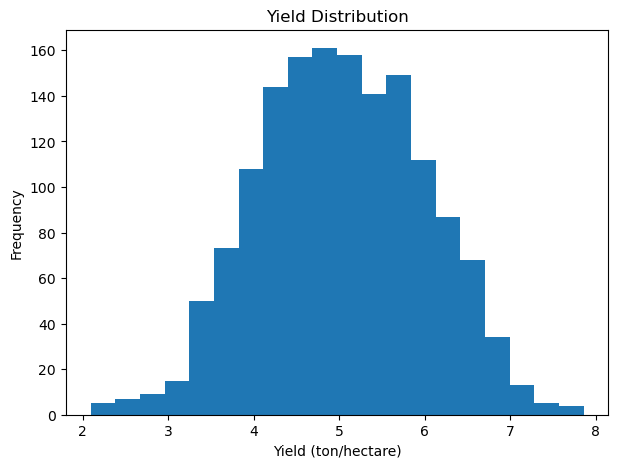

In [22]:
plt.figure(figsize=(7,5))

plt.hist(df['yield_ton_per_hectare'], bins=20)

plt.title("Yield Distribution")
plt.xlabel("Yield (ton/hectare)")
plt.ylabel("Frequency")

plt.show()

- Is the distribution approximately normal?          
Ans: Yes, the distribution is approximately normal since the histogram is roughly bell-shaped.
- Are there any noticeable outliers?       
Ans: No, no major outliers are present.

##### Q8. Scatter Plot Analysis

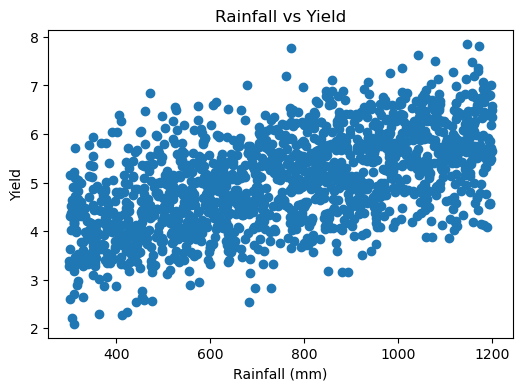

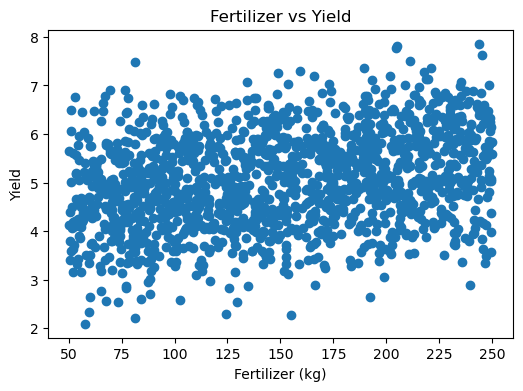

In [28]:
# Rainfall vs Yield
plt.figure(figsize=(6,4))
plt.scatter(
    df['rainfall_mm'],
    df['yield_ton_per_hectare']
)
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

# Fertilizer vs Yield
plt.figure(figsize=(6,4))
plt.scatter(
    df['fertilizer_kg'],
    df['yield_ton_per_hectare']
)
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()

- Which feature appears to have a stronger relationship with yield?             
Ans: Rainfall_mm have a stronger relationship with crop yield than fertilizer_kg because the trend between rainfall and yield is clearer and more consistent.

##### Q9. Correlation Analysis

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

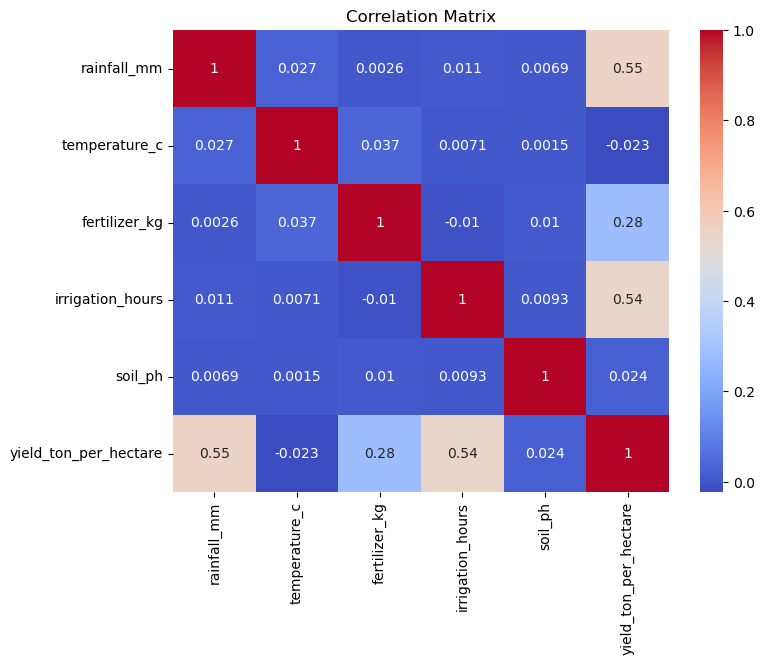

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [27]:
# Numerical columns only
corr = df.select_dtypes(include=['int64','float64']).corr()
print(corr)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

corr_with_yield = corr['yield_ton_per_hectare']
print(
    corr_with_yield
    .sort_values(ascending=False)
)

- Identify the top three features most correlated with crop yield.                  
1. rainfall_mm
2. irrigation_hours
3. fertilizer_kg

##### Q10. Group-Based Analysis

In [30]:
# Average yield by crop type

crop_avg = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print(crop_avg)
print("\nHighest Average Yield Crop:")
print(crop_avg.idxmax())
print("\n")


# Average yield by soil type

soil_avg = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print(soil_avg)
print("\nHighest Average Yield Soil:")
print(soil_avg.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Highest Average Yield Crop:
Rice


soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Highest Average Yield Soil:
Loamy


#### Part C: Data Preparation
##### Q11. Feature Encoding

In [34]:
# Categorical columns
print(df.select_dtypes(include='object').columns)

#One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)
print("\n")
print(df_encoded.head())

Index(['crop_type', 'soil_type'], dtype='object')


   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False   

   crop_type_Whe

##### Q12. Feature Selection

In [36]:
# Target variable
y = df_encoded['yield_ton_per_hectare']

# Input features
X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1500, 11)
y Shape: (1500,)


The target variable selected for prediction is yield_ton_per_hectare.
- Target Variable (y): yield_ton_per_hectare
- Input Features (X): All remaining columns after removing yield_ton_per_hectare.

#### Part D: Machine Learning
##### Q13. Train-Test Split

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1200, 11)
X_test: (300, 11)
y_train: (1200,)
y_test: (300,)


##### Q14. Linear Regression Model

In [38]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Coefficients

print("Intercept:")
print(model.intercept_)
print("\nCoefficients:")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coef_df)

# Feature with highest positive coefficient
print(
    coef_df.sort_values(
        by='Coefficient',
        ascending=False
    ).head(1)
)

Intercept:
1.5871320277361254

Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933
          Feature  Coefficient
6  crop_type_Rice     0.863993
